# EXO 1

1. Importer le fichier dans un dataframe en utilisant la fonction read_excel.

In [1]:
import pandas as pd
df = pd.read_excel("data/Produits.xlsx")

2. Afficher les 5 premières lignes du dataframe.

In [2]:
df.head(5)

,Nom,Categorie,Origine,Ville,Prix,Stock,Valeur
0,Alice Mutton,Viandes,CEE,Lyon,195.0,0,0.0
1,Aniseed Syrup,Condiments,Exterieur,Paris,50.0,25,1250.0
2,Boston Crab Meat,Poissons et fruits de mer,Exterieur,Paris,92.0,30,2760.0
3,Camembert Pierrot,Produits laitiers,Exterieur,Paris,170.0,0,0.0
4,Carnarvon Tigers,Poissons et fruits de mer,Exterieur,Lyon,312.5,0,0.0


3. Afficher un échantillon aléatoire de 10 lignes du dataframe.

In [3]:
df.sample(10)

,Nom,Categorie,Origine,Ville,Prix,Stock,Valeur
54,Rod Kaviar,Poissons et fruits de mer,CEE,Paris,75.00,5,375.0
16,Genen Shouyu,Condiments,CEE,Paris,77.50,5,387.5
9,Chef Antons Gumbo Mix,Condiments,CEE,Paris,106.75,0,0.0
47,Pavlova,Desserts,CEE,Paris,87.25,10,872.5
52,Ravioli Angelo,Pates et cereales,Exterieur,Paris,97.50,20,1950.0
31,Lakkalikoori,Boissons,CEE,Lyon,90.00,20,1800.0
56,Rossle Sauerkraut,Produits secs,CEE,Paris,228.00,0,0.0
38,Maxilaku,Desserts,CEE,Lyon,100.00,15,1500.0
70,Tourtiere,Viandes,CEE,Paris,37.25,10,372.5
65,Steeleye Stout,Boissons,Exterieur,Lyon,90.00,15,1350.0



4. Afficher les informations générales du dataframe. (methode .info())

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Nom        77 non-null     object 
 1   Categorie  77 non-null     object 
 2   Origine    77 non-null     object 
 3   Ville      77 non-null     object 
 4   Prix       77 non-null     float64
 5   Stock      77 non-null     int64  
 6   Valeur     77 non-null     float64
dtypes: float64(2), int64(1), object(4)
memory usage: 4.3+ KB



5. Extraire le Nom, Catégorie, Origine et Prix des produits, pour :
- Catégorie = boissons
- Catégorie = boissons et prix >100
- Catégorie = boissons et origine=CEE et prix > 100
- Catégorie = boissons ou catégorie = condiments
- Catégorie = boissons et origine = CEE OU catégorie = condiment
- Catégorie = viande ET origine = CEE OU catégorie = condiment ET origine = extérieur
- prix > 70 et prix <=100
- Lister les aliments dont le prix est compris entre 100 et 200, et qui sont des «viandes»
- Lister les 15 produits les moins chers


In [5]:
col = ["Nom","Categorie","Origine","Prix"]

# Catégorie= boissons
df[df["Categorie"]=="Boissons"][col]
# Catégorie= boissons et prix >100
df[(df["Categorie"]=="Boissons")&(df["Prix"]>100)][col]
# Catégorie= boissons et origine=CEE et prix > 100
df[(df["Categorie"]=="Boissons") & (df["Prix"]>100) & (df["Origine"]=="CEE")][col]
# Catégorie= boissons ou catégorie = condiments
df[(df["Categorie"]=="Boissons") | (df["Categorie"]=="Condiments")][col]
# Catégorie= boissons et origine = CEE OU catégorie = condiment
df[(df["Categorie"]=="Boissons")&(df["Origine"]=="CEE")|(df["Categorie"]=="Condiments")][col]
# Catégorie= viande ET origine = CEE OU catégorie = condiment ET origine = extérieur
df[(df["Categorie"]=="Viandes")&(df["Origine"]=="CEE") | (df["Categorie"]=="Condiments")&(df["Origine"]=="Exterieur")][col]
# prix > 70 et prix <=100
df[(df["Prix"]>70) & (df["Prix"]<=100)][col]

,Nom,Categorie,Origine,Prix
2,Boston Crab Meat,Poissons et fruits de mer,Exterieur,92.00
5,Chai,Boissons,CEE,90.00
6,Chang,Boissons,Exterieur,95.00
7,Chartreuse verte,Boissons,Exterieur,90.00
16,Genen Shouyu,Condiments,CEE,77.50
23,Gula Malacca,Condiments,CEE,97.25
27,Inlagd Sill,Poissons et fruits de mer,Exterieur,95.00
31,Lakkalikoori,Boissons,CEE,90.00
35,Louisiana Hot Spiced Okra,Condiments,CEE,85.00
38,Maxilaku,Desserts,CEE,100.00


In [6]:
# Lister les aliments dont le prix est compris entre 100 et 200, et qui sont des «viandes»
df["Nom"][df["Categorie"]=="Viandes"][df["Prix"]>=100][df["Prix"]<=200]
# Lister les 15 produits les moins chers
df.sort_values("Prix").head(15)["Nom"]

15                           Geitost
21                Guarana Fantastica
30                             Konbu
13                          Filo Mix
70                         Tourtiere
53              Rhonbrau Klosterbier
71                          Tunnbrod
67        Teatime Chocolate Biscuits
76                     Zaanse koeken
55                       Røgede sild
29    Jacks New England Clam Chowder
1                      Aniseed Syrup
62                Sir Rodneys Scones
33                     Longlife Tofu
64                         Spegesild
Name: Nom, dtype: object

6. Calculer la moyenne de prix des boissons distribuées à Lyon (pivot_table)

In [7]:
pd.pivot_table(df[ (df["Ville"] == "Lyon")], index = ["Categorie"],columns=["Ville"], values=["Prix"] , aggfunc='mean'   )

,Prix
Ville,Lyon
Categorie,
Boissons,76.944444
Condiments,125.000000
Desserts,119.750000
Pates et cereales,142.083333
Poissons et fruits de mer,118.366667
Produits laitiers,103.300000
Produits secs,143.750000
Viandes,354.737500



7. Quels sont les 5 produits les moins chers vendus à Lyon?

In [8]:
df[df["Ville"]=="Lyon"].sort_values("Prix").head()["Nom"]

15                       Geitost
21            Guarana Fantastica
30                         Konbu
67    Teatime Chocolate Biscuits
76                 Zaanse koeken
Name: Nom, dtype: object

# EXO 2

1. Importer le fichier dans un dataframe en utilisant la fonction read_csv.

In [11]:
data = pd.read_csv('data/us_crime_rates.csv')
data_init = pd.read_csv('data/us_crime_rates.csv')


2. Afficher les 5 premières lignes du dataframe.


In [12]:
data.head()

,Year,Population,Total,Violent,Property,Murder,Forcible_Rape,Robbery,Aggravated_assault,Burglary,Larceny_Theft,Vehicle_Theft
0,1960,179323175,3384200,288460,3095700,9110,17190,107840,154320,912100,1855400,328200
1,1961,182992000,3488000,289390,3198600,8740,17220,106670,156760,949600,1913000,336000
2,1962,185771000,3752200,301510,3450700,8530,17550,110860,164570,994300,2089600,366800
3,1963,188483000,4109500,316970,3792500,8640,17650,116470,174210,1086400,2297800,408300
4,1964,191141000,4564600,364220,4200400,9360,21420,130390,203050,1213200,2514400,472800


3. Créer le dataframe qui donne chaque indicateur pour chaque décennie. (.resample())


In [ ]:
data = data_init
data.Year = pd.to_datetime(data.Year, format='%Y')

data = data.set_index('Year', drop = True)
population = data['Population'].resample('10YS').max()      # /!\ ici on traite differament la population car la somme d'une population sur 10 ans n'a aucun sens 
                                                            # On prefère généralement utilisé le maximum ou la moyenne
del data['Total']

data = data.resample('10YS').sum()

data['Population'] = population

data.head(10)

,Population,Violent,Property,Murder,Forcible_Rape,Robbery,Aggravated_assault,Burglary,Larceny_Theft,Vehicle_Theft
Year,,,,,,,,,,
1960-01-01,201385000,4134930,45160900,106180,236720,1633510,2158520,13321100,26547700,5292100
1970-01-01,220099000,9607930,91383800,192230,554570,4159020,4702120,28486000,53157800,9739900
1980-01-01,248239000,14074328,117048900,206439,865639,5383109,7619130,33073494,72040253,11935411
1990-01-01,272690813,17527048,119053499,211664,998827,5748930,10568963,26750015,77679366,14624418
2000-01-01,307006550,13968056,100944369,163068,922499,4230366,8652124,21565176,67970291,11412834
2010-01-01,318857056,6072017,44095950,72867,421059,1749809,3764142,10125170,30401698,3569080


4. Quel était la décennie la plus dangereuse ?


In [14]:
data.idxmax(0)

Population           2010-01-01
Violent              1990-01-01
Property             1990-01-01
Murder               1990-01-01
Forcible_Rape        1990-01-01
Robbery              1990-01-01
Aggravated_assault   1990-01-01
Burglary             1980-01-01
Larceny_Theft        1990-01-01
Vehicle_Theft        1990-01-01
dtype: datetime64[ns]

On peut donc dire qu'il s'agit des années 90. 

5. Afficher l'évolution du nombre de meurtre par décennie.

<Axes: xlabel='Year'>

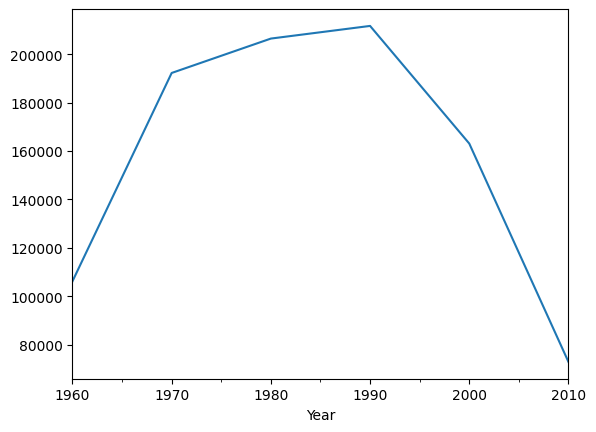

In [17]:
data["Murder"].plot()